____
# Test level of ggd noise after gaussian smoothing


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [14]:
def E_ggd_from_noisemaps(dsn, cutoff, mask, dx, dy):
    from altimetry_filter import apply_gaussian_filter, apply_stencil_diff
    if cutoff==0:
        dsf = dsn.where(mask).rename('noise_ssh').to_dataset()
        for var in ['dx', 'dy'] : 
            dsf['g'+var] = 9.81*apply_stencil_diff(dsf.noise_ssh, var, dx=dx, dy=dy)
    else :
        dsf = apply_gaussian_filter(dsn, cutoff,  mask, dx, dy).where(mask).rename('noise_ssh').to_dataset()
        for var in ['dx', 'dy'] : 
            dsf['g'+var] = 9.81*apply_stencil_diff(dsf.noise_ssh, var, dx=dx, dy=dy)
    MS = (dsf.gdx**2).mean() + (dsf.gdy**2).mean()
    VAR = dsf.gdx.var() + dsf.gdy.var()
    return MS/U2, VAR/U2

def generate_swot_noise(dss, sigma):
    noise = np.random.rand(dss.sizes['num_lines'],dss.sizes['num_pixels'])-0.5
    noise = sigma*noise/np.std(noise)
    dsn = xr.DataArray(noise, dict(num_lines=('num_lines', dss.num_lines.values), num_pixels=('num_pixels', dss.num_pixels.values)))
    return dsn.where(dss.duacs_editing_flag==0)

# Generate white noise on SWOT

In [5]:
sigmassh = 4e-3
from swot import browse_swot_2km, add_grid_metrics
dfs = browse_swot_2km()
dss = xr.open_dataset(dfs.file.iloc[0])
dss = add_grid_metrics(dss)
dx = float(dss.dx.mean())
dy = float(dss.dy.mean())

dsn = generate_swot_noise(dss, sigmassh)
mask = dss.duacs_editing_flag.where(dss.duacs_editing_flag!=0,1).where(dss.duacs_editing_flag==0,0)



/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


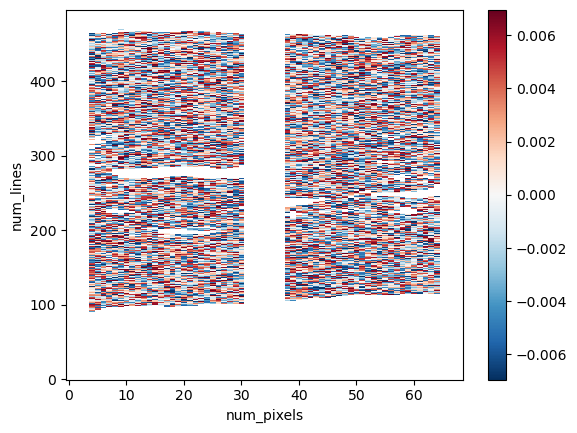

In [6]:
dsn.plot()

In [15]:
# loop
Sigmassh = np.arange(1e-3, 10e-3, 5e-4)#m
cutoff = np.arange(0, 60e3, 5e2)
MS=[]
VAR=[]
for sigmassh in Sigmassh:
    dsn = generate_swot_noise(dss, sigmassh)
    ms_, var_ = E_ggd_from_noisemaps(dsn, 0, mask, dx, dy)
    MS.append(ms_.values)
    VAR.append(var_.values)


def func(sigma, a):
    return a*sigma**2
    
from scipy.optimize import curve_fit
popt, pcov = curve_fit(func, Sigmassh, MS)
ig = func(Sigmassh, *popt)


In [40]:
def MSnoiseggd_from_sshnoisestd(sigmaN, d=2e3) : 
    """ 
    sigmaN : white noise std in m
    d : grid spacing in m
    """
    print('Caution : std must be given in m, E_ggd given in gamma^2')
    from cstes import U2
    g=9.81
    K = -sum(np.arange(0, 9)*[1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280])
    b=(1/280)**2 + (4/105)**2+ (1/5)**2+(4/5)**2
    return 4*g**2/(K**2)/(d**2)*b*(sigmaN**2)/U2

def sshnoisestd_from_MSnoiseggd(E_ggd, d=2e3) : 
    """ 
    E_ggd : pressure gradient MS in gamma^2
    d : grid spacing in m
    """
    print('Caution : E_ggd must be given in gamma^2, std must return in m')
    from cstes import U2
    g=9.81
    K = -sum(np.arange(0, 9)*[1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280])
    b=(1/280)**2 + (4/105)**2+ (1/5)**2+(4/5)**2
    
    return np.sqrt(E_ggd*U2*(K*d)**2/(4*g**2*b))

E_ggd = MSnoiseggd_from_sshnoisestd(Sigmassh, d=2e3)
ss = sshnoisestd_from_MSnoiseggd(E_ggd)

Caution : std must be given in m, E_ggd given in gamma^2
Caution : E_ggd must be given in gamma^2, std must return in m


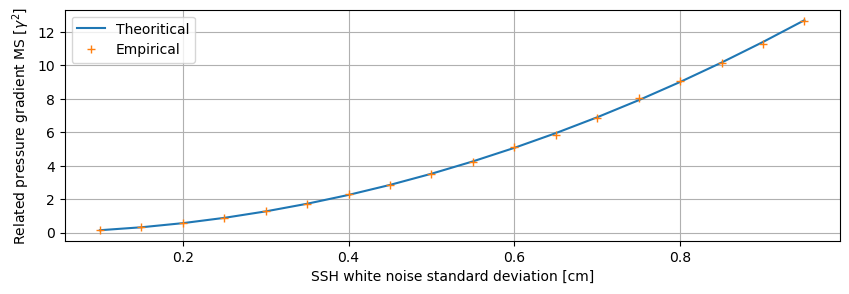

In [37]:
fig, ax = plt.subplots(1, 1, figsize = (10, 3),  frameon=False)
#ax.plot(Sigmassh, ig, label = 'Fit')
ax.plot(Sigmassh*1e2, E_ggd, label = 'Theoritical')
ax.plot(Sigmassh*1e2, MS, label = 'Empirical', ls='', marker='+')
ax.set_xlabel('SSH white noise standard deviation [cm]')
ax.set_ylabel(r'Related pressure gradient MS [$\gamma^2$]')
ax.grid()
ax.legend()

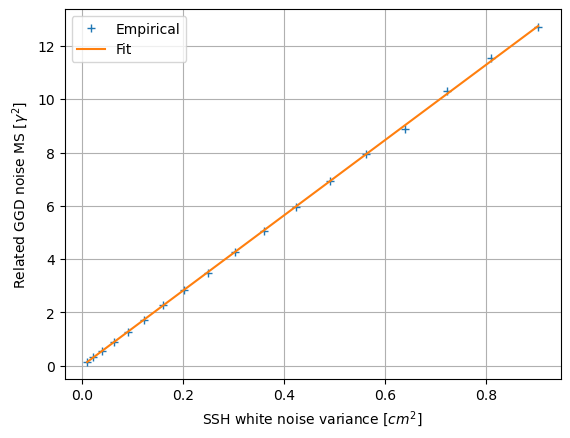

In [12]:
fig, ax = plt.subplots(1, 1, frameon=False)
ax.plot(Sigmassh**2/1e-4, MS, label = 'Empirical', ls='', marker='+')
ax.plot(Sigmassh**2/1e-4, ig, label = 'Fit')
ax.set_xlabel(r'SSH white noise variance [$cm^2$]')
ax.set_ylabel(r'Related GGD noise MS [$\gamma^2$]')
ax.grid()
ax.legend()

_______
# Gaussian filter

In [9]:
def noise_gaussian_MS():
    # swot image
    from swot import browse_swot_2km, add_grid_metrics
    dfs = browse_swot_2km()
    dss = xr.open_dataset(dfs.file.iloc[0])
    dss = add_grid_metrics(dss)
    dx = float(dss.dx.mean())
    dy = float(dss.dy.mean())

    mask = dss.duacs_editing_flag.where(dss.duacs_editing_flag!=0,1).where(dss.duacs_editing_flag==0,0)

    # loop
    Sigmassh = np.arange(1e-3, 6e-3, 5e-4)
    cutoff = np.arange(0, 60e3, 5e2)
    MS=[]
    VAR=[]
    for sigmassh in Sigmassh:
        dsn = generate_swot_noise(dss, sigmassh)
        ms=[]
        var=[]
        for ct in cutoff:
            ms_, var_ = gaussian_ms_var_gaussian(dsn, ct, mask, dx, dy)
            ms.append(ms_.values)
            var.append(var_.values)
        print(len(ms))
        MS.append(xr.DataArray(ms, coords={'cutoff':('cutoff', cutoff)}))
        VAR.append(xr.DataArray(var, coords={'cutoff':('cutoff', cutoff)}))
    return xr.concat(MS, dim = pd.Index(Sigmassh, name = 'sigmassh'))

dsms = noise_gaussian_MS()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


120
120
120
120
120
120
120
120
120
120


In [35]:
dsms['sigmassh'] = np.round(dsms['sigmassh'],4).assign_attrs({'long_name':'SSH white noise standard deviation'})

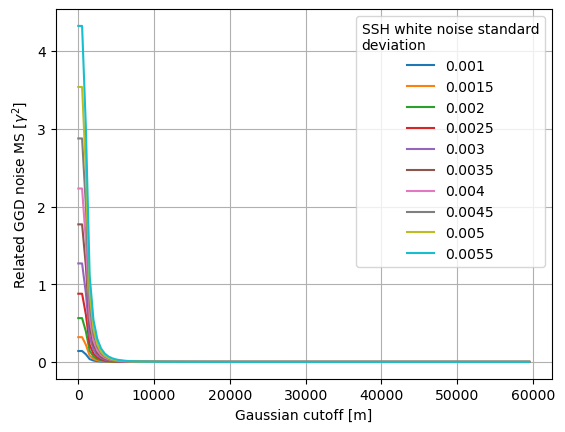

In [36]:
fig, ax = plt.subplots(1, 1, frameon=False)
dsms.rename('ms_noise_ggd').plot(hue='sigmassh', ax=ax)
#ax.set_xlabel('SSH white noise standard deviation [m]')
ax.set_ylabel(r'Related GGD noise MS [$\gamma^2$]')
ax.set_xlabel('Gaussian cutoff [m]')
ax.grid()

In [20]:
dsms.rename('ms_noise_ggd').to_netcdf(os.path.join(zarr_dir, 'diag_files', 'ms_noise_gaussian.nc'))